### Fetching Data

In [1]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [2]:
X_train.to_parquet('data/train/features.parquet', index=False)
y_train.to_parquet('data/train/targets.parquet', index=False)

X_test.to_parquet('data/test/features.parquet', index=False)
y_test.to_parquet('data/test/targets.parquet', index=False)

### Train the VAE

In [5]:
import pandas as pd
import numpy as np
import torch

In [6]:
from datasets import WDBCDataModule
from models import TabularVAE
from l_modules import VAEModule
from generate import generate_synthetic_data

In [7]:
import lightning as l
from pytorch_lightning.loggers import WandbLogger

wandb_logger = WandbLogger(entity="tomos_playground", project='DS4420-Project')

model = TabularVAE(input_dim=31, latent_dim=16)
data_module = WDBCDataModule(mode='train', batch_size=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
trainer = l.Trainer(
    max_epochs=100,
    accelerator='auto',
    log_every_n_steps=1,
    logger=wandb_logger,
)

vae_module = VAEModule(model, optimizer)
trainer.fit(vae_module, data_module)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ TabularVAE │ 27.8 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 27.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


`Trainer.fit` stopped: `max_epochs=100` reached.


In [8]:
wandb_logger.experiment.finish()

KullbackLeiblerDiv,▁▁▁▁▁▁▁▂▇▆▆▅▅▅▅▅▅▅▆▅▆▆▇▇▇▇▇▇▇▇██████████
ReconstructionLoss,███████▇▇▆▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
ReconstructionLoss_Feats,██████████▆▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
ReconstructionLoss_Targets,███████▇▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁
VAELoss,████████▇▅▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
trainer/global_step,▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
KullbackLeiblerDiv,119.74123
ReconstructionLoss,394.04785
ReconstructionLoss_Feats,385.29166
ReconstructionLoss_Targets,8.75624


A helpful heuristic for seeing how well the model generates data is by doing a direct UMAP projection of our test data against our synthetically generated data and see how well they overlap:

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


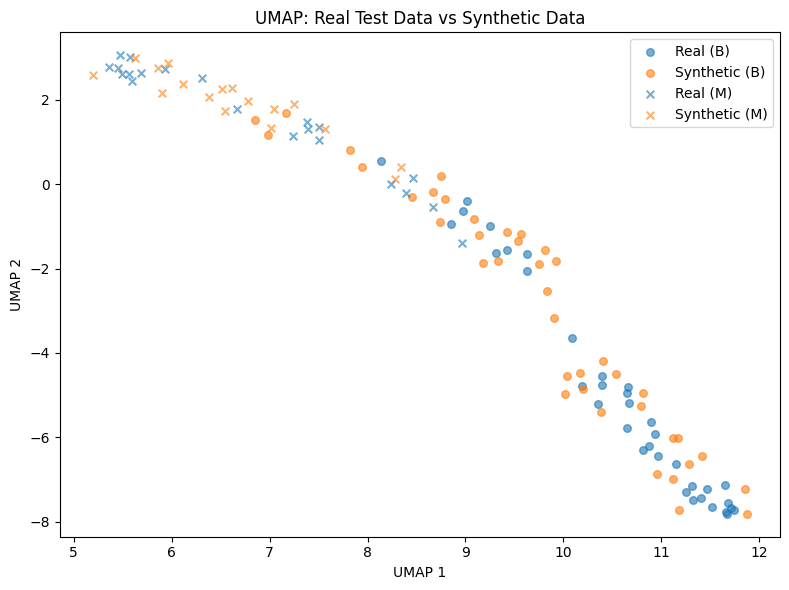

In [9]:
import umap
import matplotlib.pyplot as plt

# Load test data in original scale
X_test_raw = pd.read_parquet('data/test/features.parquet')
y_test_raw = pd.read_parquet('data/test/targets.parquet').squeeze()
y_test_binary = pd.get_dummies(y_test_raw, drop_first=True).values.ravel()

# Generate synthetic data (same size as test set)
synthetic_df = generate_synthetic_data(model, data_module, num_samples=len(X_test_raw))
X_synth = synthetic_df[data_module.feature_columns].values
y_synth = synthetic_df[data_module.target_column].values

# Combine real and synthetic features, then fit UMAP
X_combined = np.vstack([X_test_raw.values, X_synth])

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_combined)

emb_real = embedding[:len(X_test_raw)]
emb_synth = embedding[len(X_test_raw):]

# Plot with source as color and diagnosis as marker
fig, ax = plt.subplots(figsize=(8, 6))

for diag, marker in [(0, 'o'), (1, 'x')]:
    mask_real = y_test_binary == diag
    ax.scatter(emb_real[mask_real, 0], emb_real[mask_real, 1],
               marker=marker, alpha=0.6, s=30, c='tab:blue',
               label=f'Real ({"M" if diag else "B"})')

    mask_synth = y_synth == diag
    ax.scatter(emb_synth[mask_synth, 0], emb_synth[mask_synth, 1],
               marker=marker, alpha=0.6, s=30, c='tab:orange',
               label=f'Synthetic ({"M" if diag else "B"})')

ax.set_title('UMAP: Real Test Data vs Synthetic Data')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()
plt.tight_layout()
plt.show()